In [1]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
import sklearn
from scipy.signal import find_peaks, welch
from lib.readwav import *

In [ ]:

%matplotlib widget
plt.close('all')

# funziona davvero

file con possibili problemi da investigare meglio: 36, 108, 244

file 244 salva metà della frequenza fondamentale (risultando nell'unica nota sotto i 40 Hz), quindi ho messo una condizione per verificare se la frequenza fondamentale stimata è sotto i 40 Hz, in quel caso la raddoppio. Non so se è un problema legato a questo o alla funzione f0_MCD, da investigare meglio.

il file 108 salva solo male i valori del power spectrum delle armoniche stimate, non riesco a capire se è un problema legato alla stima della frequenza fondamentale o alla ricerca dei picchi, da investigare meglio.

Il file 36 sembra che parta tutto dalla armonica fondamentale.


In [221]:
# leggiamo un singolo file audio
rate, note = readwav('./wav_files/note_256.wav')

In [222]:
#togliamo il primo 25% del segnale e l'ultimo 10% e plotto mantenendo i secondi corretti
note = note[:, 0] # prendo solo un canale se il segnale è stereo

start = int(len(note) * 0.25)
end = int(len(note) * 0.9)
note = note[start:end]
time = np.arange(len(note)) / rate

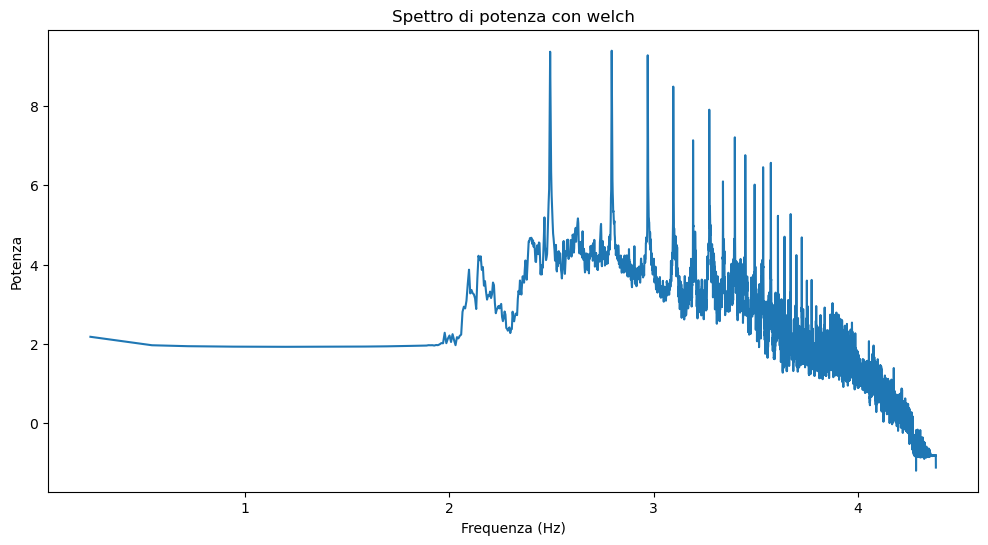

In [223]:
sigma = 10000

gaussian_window = scipy.signal.windows.gaussian(len(note)//10, std=sigma)

frequencies, spectrum = welch(note, fs=rate, nperseg=len(gaussian_window), window=gaussian_window)

log_frequencies = np.log10(frequencies[1:])
log_spectrum = np.log10(spectrum[1:])

plt.figure(figsize=(12, 6))
plt.plot(log_frequencies, log_spectrum)
plt.title('Spettro di potenza con welch')
plt.xlabel('Frequenza (Hz)')
plt.ylabel('Potenza')
plt.show()

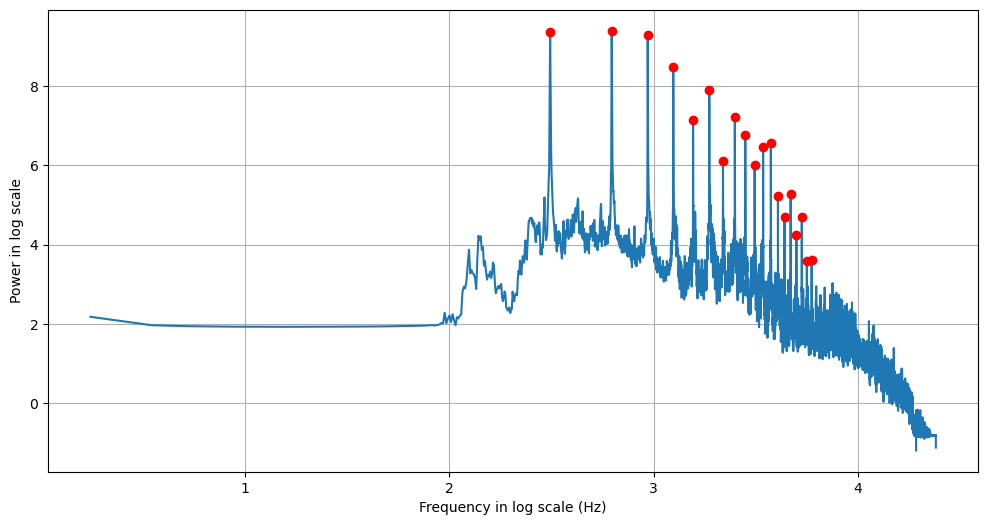

In [249]:
prom = 2
peaks, _ = find_peaks(log_spectrum, prominence=prom)

# segnamole sul grafico
plt.figure(figsize=(12, 6))
plt.plot(log_frequencies, log_spectrum)
plt.plot(log_frequencies[peaks], log_spectrum[peaks], 'ro')
plt.xlabel('Frequency in log scale (Hz)')
plt.ylabel('Power in log scale')
#plt.title('Average Power Spectrum with Gaussian Windowing and Peaks')
plt.grid()
plt.show()

In [250]:
#prendo tra i picchi quello che ha il power spectrum massimo
index_max_peak = np.argmax(log_spectrum[peaks])
freq_limite = 10**log_frequencies[peaks][index_max_peak]


# troviamo il massimo comun divisore delle differenze
def f0_MCD(picchi, limite):
    minimo = np.min(picchi) / 2
    massimo = limite
    # Risoluzione 0.1 Hz
    candidati = np.arange(minimo, massimo + 0.1, 0.1)
    
    # dall'alto verso il basso
    candidati = candidati[::-1]

    residuo_minimo = float('inf')
    migliore_f0 = minimo

    for f0 in candidati:
        rapporto = picchi / f0
        interi = np.round(rapporto)
        
        if np.any(interi == 0):
            continue

        # distanza tra i rapporti e gli interi
        distanze = np.abs(rapporto - interi)
        residuo_base = np.sum(distanze)

        armoniche_coperte = len(np.unique(interi))
        massima_armonica = np.max(interi)
        
        vuoti = massima_armonica - armoniche_coperte
        penalita_vuoti = vuoti * 0.1  # Peso regolabile

        residuo_attuale = residuo_base + penalita_vuoti

        # uso un margine per non cambiare f0 se il miglioramento è minimo
        if residuo_attuale < residuo_minimo * 0.95:
            residuo_minimo = residuo_attuale
            migliore_f0 = f0

    return migliore_f0

frequencies_peaks = 10**log_frequencies[peaks]
# stimiamo la frequenza fondamentale
f0 = f0_MCD(frequencies_peaks, freq_limite)

#la condizione messa è di verifica, per vedere se i 4 file strani hanno un problema legato a questo
if(f0 < 40):
    f0 = f0*2
print(f'Frequenza fondamentale stimata: {f0:.2f} Hz')


Frequenza fondamentale stimata: 311.85 Hz


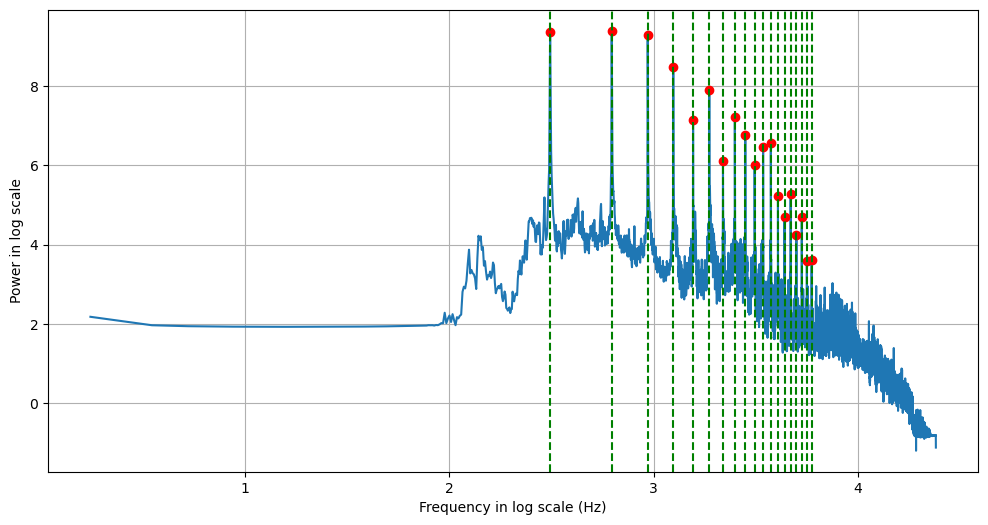

In [251]:
# prendiamo la f0 stimata e calcoliamo le armoniche successive ( tipo altre 10)
armoniche_stimate = { f0*i  for i in range(1,20)}

#grafico con le armoniche stimate
plt.figure(figsize=(12, 6))
plt.plot(log_frequencies, log_spectrum)
plt.plot(log_frequencies[peaks], log_spectrum[peaks], 'ro')
for armonica in armoniche_stimate:
    plt.axvline(x=np.log10(armonica), color='g', linestyle='--')
plt.xlabel('Frequency in log scale (Hz)')
plt.ylabel('Power in log scale')
plt.grid()
plt.show()



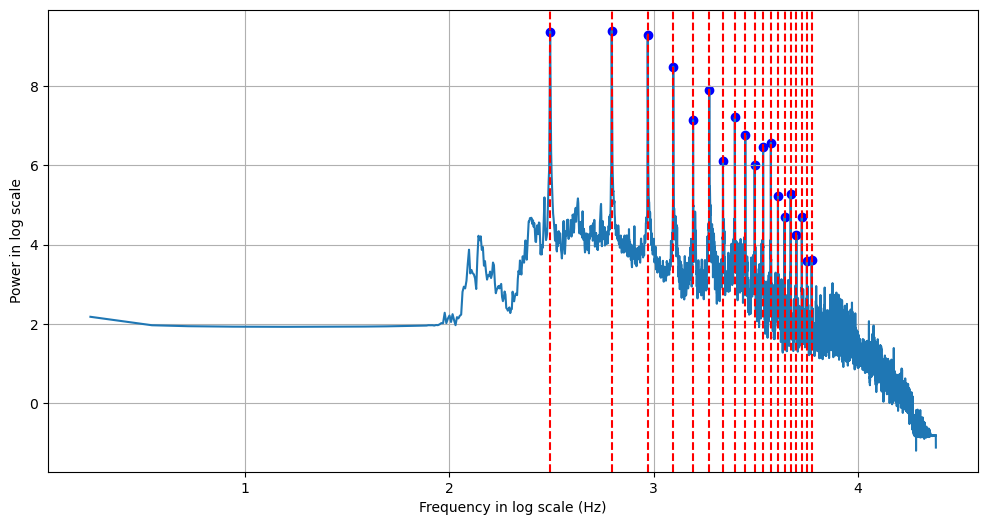

In [252]:
# salvo i valori di power spectrum di queste armoniche stimate
power_armoniche = []
armoniche_stimate = sorted(list(armoniche_stimate))
tolleranza_picco = 0.04  # 0,03 va bene fino al file 108
for armonica in armoniche_stimate:
    log_armonica = np.log10(armonica)
    # Trova se c'è un picco trovato vicino all'armonica
    distanza_picchi = np.abs(log_frequencies[peaks] - log_armonica)
    if np.any(distanza_picchi < tolleranza_picco):
        # Se c'è un picco vicino, prendo il valore del picco
        indice_picco = peaks[np.argmin(distanza_picchi)]
        power_armoniche.append(log_spectrum[indice_picco])
    else:
        # Altrimenti prendo il valore più vicino
        distanza = np.abs(log_frequencies - log_armonica)
        indice_vicino = np.argmin(distanza)
        power_armoniche.append(log_spectrum[indice_vicino])

power_f0 = power_armoniche[0]

# normalizzo i valori di potenza delle armoniche rispetto alla potenza del picco fondamentale
power_armoniche = np.array(power_armoniche)
power_armoniche_normalizzate = power_armoniche - power_f0

# visualizzo valori come dei puntini blu sul grafico del power spectrum
plt.figure(figsize=(12, 6))
plt.plot(log_frequencies, log_spectrum)
plt.scatter(np.log10(armoniche_stimate), power_armoniche, color='blue')
for armonica in armoniche_stimate:
    plt.axvline(np.log10(armonica), color='red', linestyle='--')
plt.xlabel('Frequency in log scale (Hz)')
plt.ylabel('Power in log scale')
plt.grid()
plt.show()
